# Step 1 — Loading & Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/dataset-diabete.csv")

print(df.shape)
print(df.dtypes)
print(df.head())

print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

zero_check_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_check_cols:
    print(col, "zeros:", (df[col] == 0).sum())

print(df.describe())

(768, 8)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
dtype: object
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  
Pregnancies                 0
Glucose         

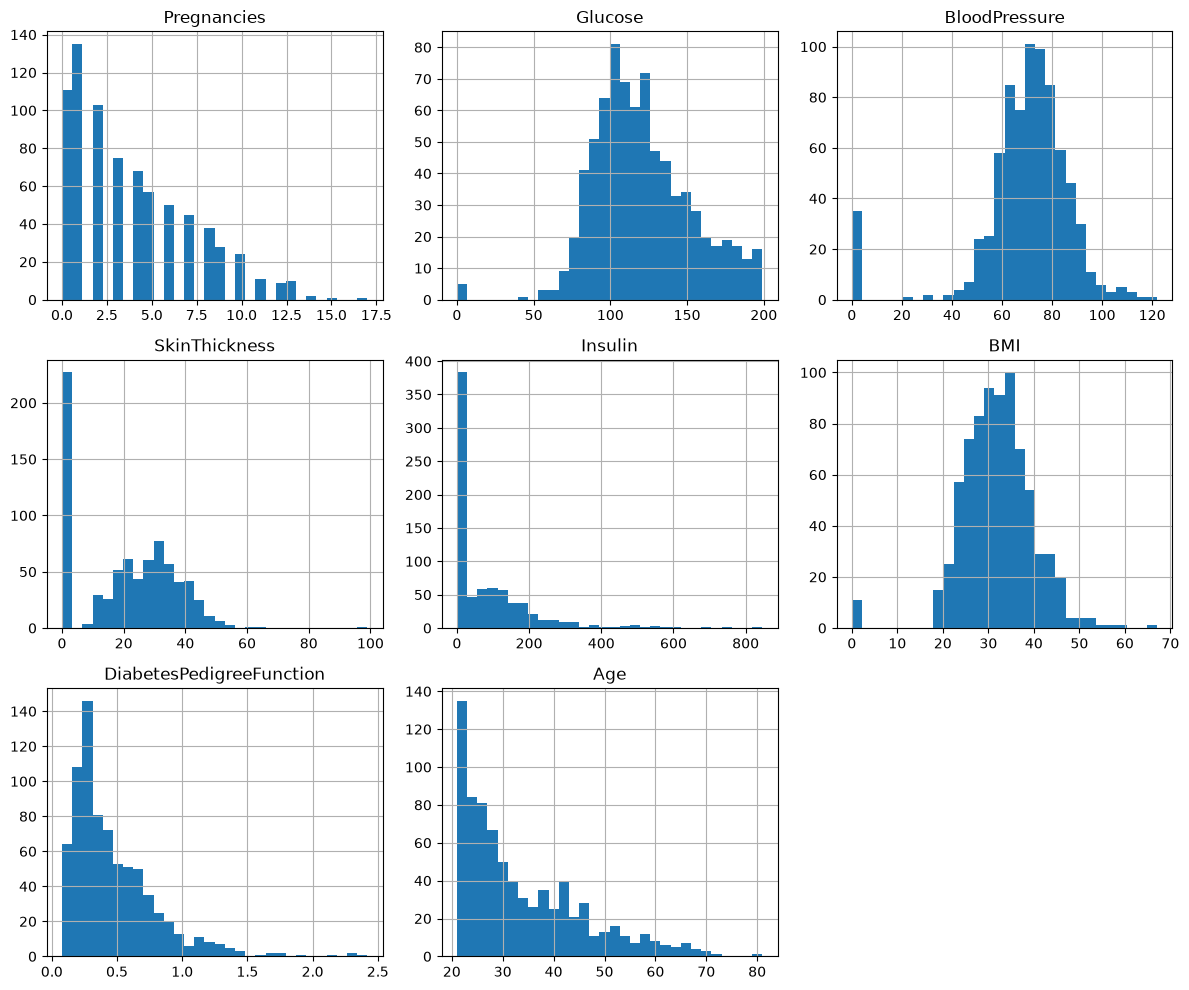

In [3]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.savefig("../notebooks/distributions.png")
plt.show()

# Step 2 — Preprocessing

## 2.1 Missing-value pattern (fake zeros treated as NaN)

In [4]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_check = df.copy()
df_check[cols] = df_check[cols].replace(0, np.nan)

missing_per_row = df_check[cols].isnull().sum(axis=1)
df_check["missing_count"] = missing_per_row

print(missing_per_row.value_counts().sort_index())

for n in [2, 3, 4]:
    subset = df_check[df_check["missing_count"] == n]
    print(f"\n=== Rows missing {n} values ({len(subset)} rows) ===")
    print(subset)

0    392
1    142
2    199
3     28
4      7
Name: count, dtype: int64

=== Rows missing 2 values (199 rows) ===
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
2              8    183.0           64.0            NaN      NaN  23.3   
5              5    116.0           74.0            NaN      NaN  25.6   
10             4    110.0           92.0            NaN      NaN  37.6   
11            10    168.0           74.0            NaN      NaN  38.0   
12            10    139.0           80.0            NaN      NaN  27.1   
..           ...      ...            ...            ...      ...   ...   
757            0    123.0           72.0            NaN      NaN  36.3   
758            1    106.0           76.0            NaN      NaN  37.5   
759            6    190.0           92.0            NaN      NaN  35.5   
762            9     89.0           62.0            NaN      NaN  22.5   
766            1    126.0           60.0            NaN      NaN  30.1   

Findings: rows missing 2 values are always SkinThickness + Insulin together. Rows missing 3 add BloodPressure. Rows missing 4 (7 rows) are missing BloodPressure, SkinThickness, Insulin and BMI all at once — dropped below.

## 2.2 Imputation (MICE) + cleanup

In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = pd.read_csv("../data/dataset-diabete.csv")

cols_with_fake_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_fake_zeros] = df[cols_with_fake_zeros].replace(0, np.nan)

missing_per_row = df[cols_with_fake_zeros].isnull().sum(axis=1)
df = df[missing_per_row < 4].reset_index(drop=True)

all_numeric_cols = df.columns.tolist()
imputer = IterativeImputer(random_state=42)
df[all_numeric_cols] = imputer.fit_transform(df[all_numeric_cols])

df["Pregnancies"] = df["Pregnancies"].round().astype(int)
df["Age"] = df["Age"].round().astype(int)

cols_min_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction"]
df[cols_min_zero] = df[cols_min_zero].clip(lower=0)

print(df.isnull().sum())
print(df.shape)
print(df.describe())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
(761, 8)
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   761.000000  761.000000     761.000000     761.000000  761.000000   
mean      3.840999  121.887210      72.389339      28.927858  153.243855   
std       3.370491   30.463445      12.195348       9.562158   97.515849   
min       0.000000   44.000000      24.000000       7.000000    0.000000   
25%       1.000000  100.000000      64.000000      22.000000   90.000000   
50%       3.000000  117.000000      72.000000      28.629014  130.622778   
75%       6.000000  141.000000      80.000000      35.000000  190.000000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         A

## 2.3 Outlier detection (IQR)

Outliers kept as-is — flagged values are physiologically plausible, not data errors. Influence on clustering handled via RobustScaler below.

Column                            Lower      Upper  #Outliers
Pregnancies                       -6.50      13.50          4
Glucose                           38.50     202.50          0
BloodPressure                     40.00     104.00         14
SkinThickness                      2.50      54.50          4
Insulin                          -60.00     340.00         27
BMI                               13.85      50.25          8
DiabetesPedigreeFunction          -0.33       1.21         29
Age                               -1.50      66.50          9


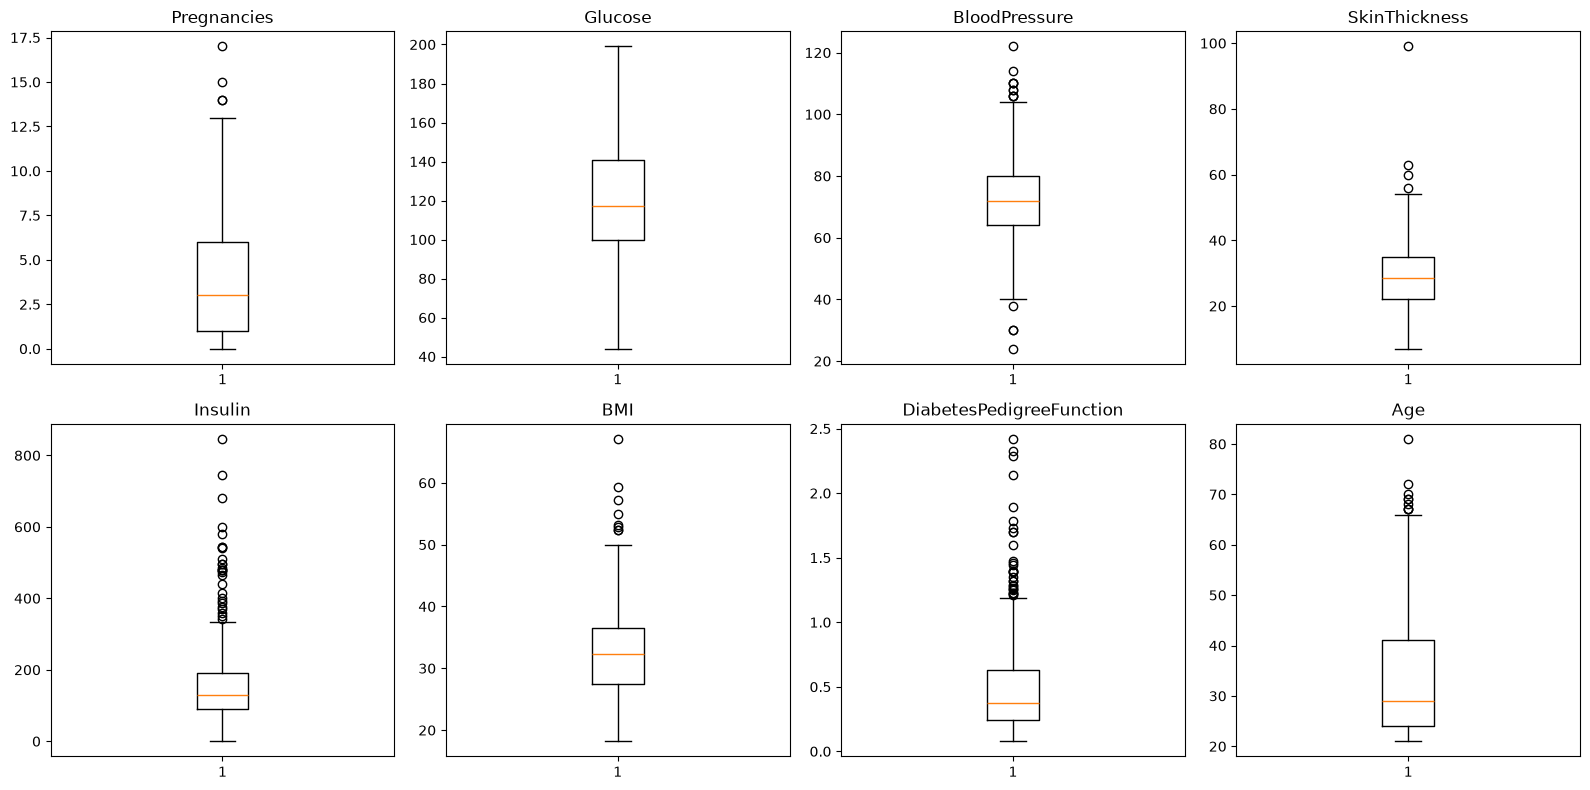

In [6]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

numeric_cols = df.columns.tolist()

print(f"{'Column':<28} {'Lower':>10} {'Upper':>10} {'#Outliers':>10}")
for col in numeric_cols:
    low, high = iqr_bounds(df[col])
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:<28} {low:>10.2f} {high:>10.2f} {n_out:>10}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../notebooks/boxplots.png")
plt.show()

## 2.4 Correlation analysis + variable selection

Strongest correlations: SkinThickness-BMI (0.71), Glucose-Insulin (0.70). Keeping all 8 features — not high enough to count as redundant, both pairs clinically meaningful on their own.

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128836       0.213757       0.106677   
Glucose                      0.128836  1.000000       0.228290       0.242071   
BloodPressure                0.213757  0.228290       1.000000       0.242007   
SkinThickness                0.106677  0.242071       0.242007       1.000000   
Insulin                      0.069162  0.697353       0.137199       0.249947   
BMI                          0.023189  0.234678       0.295921       0.705994   
DiabetesPedigreeFunction    -0.033328  0.133213       0.000749       0.120775   
Age                          0.547661  0.263866       0.333293       0.150730   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.069162  0.023189                 -0.033328   
Glucose                   0.697353  0.234678                  0.133213   
BloodPressure             0.137199  0.295921    

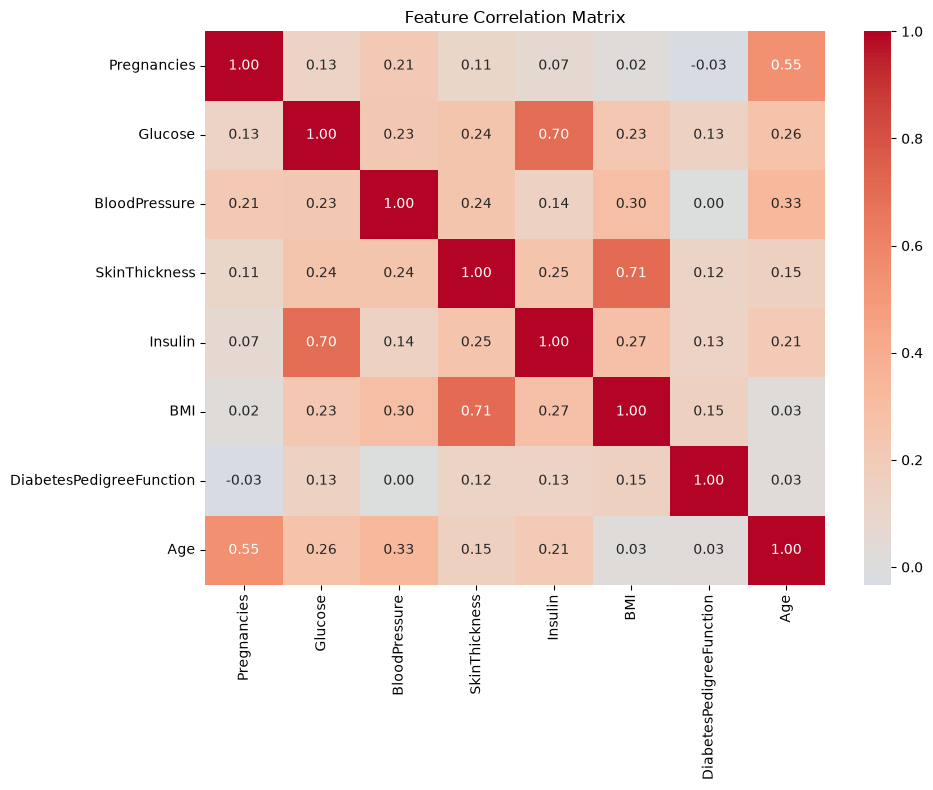

In [7]:
corr = df.corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../notebooks/correlation_heatmap.png")
plt.show()

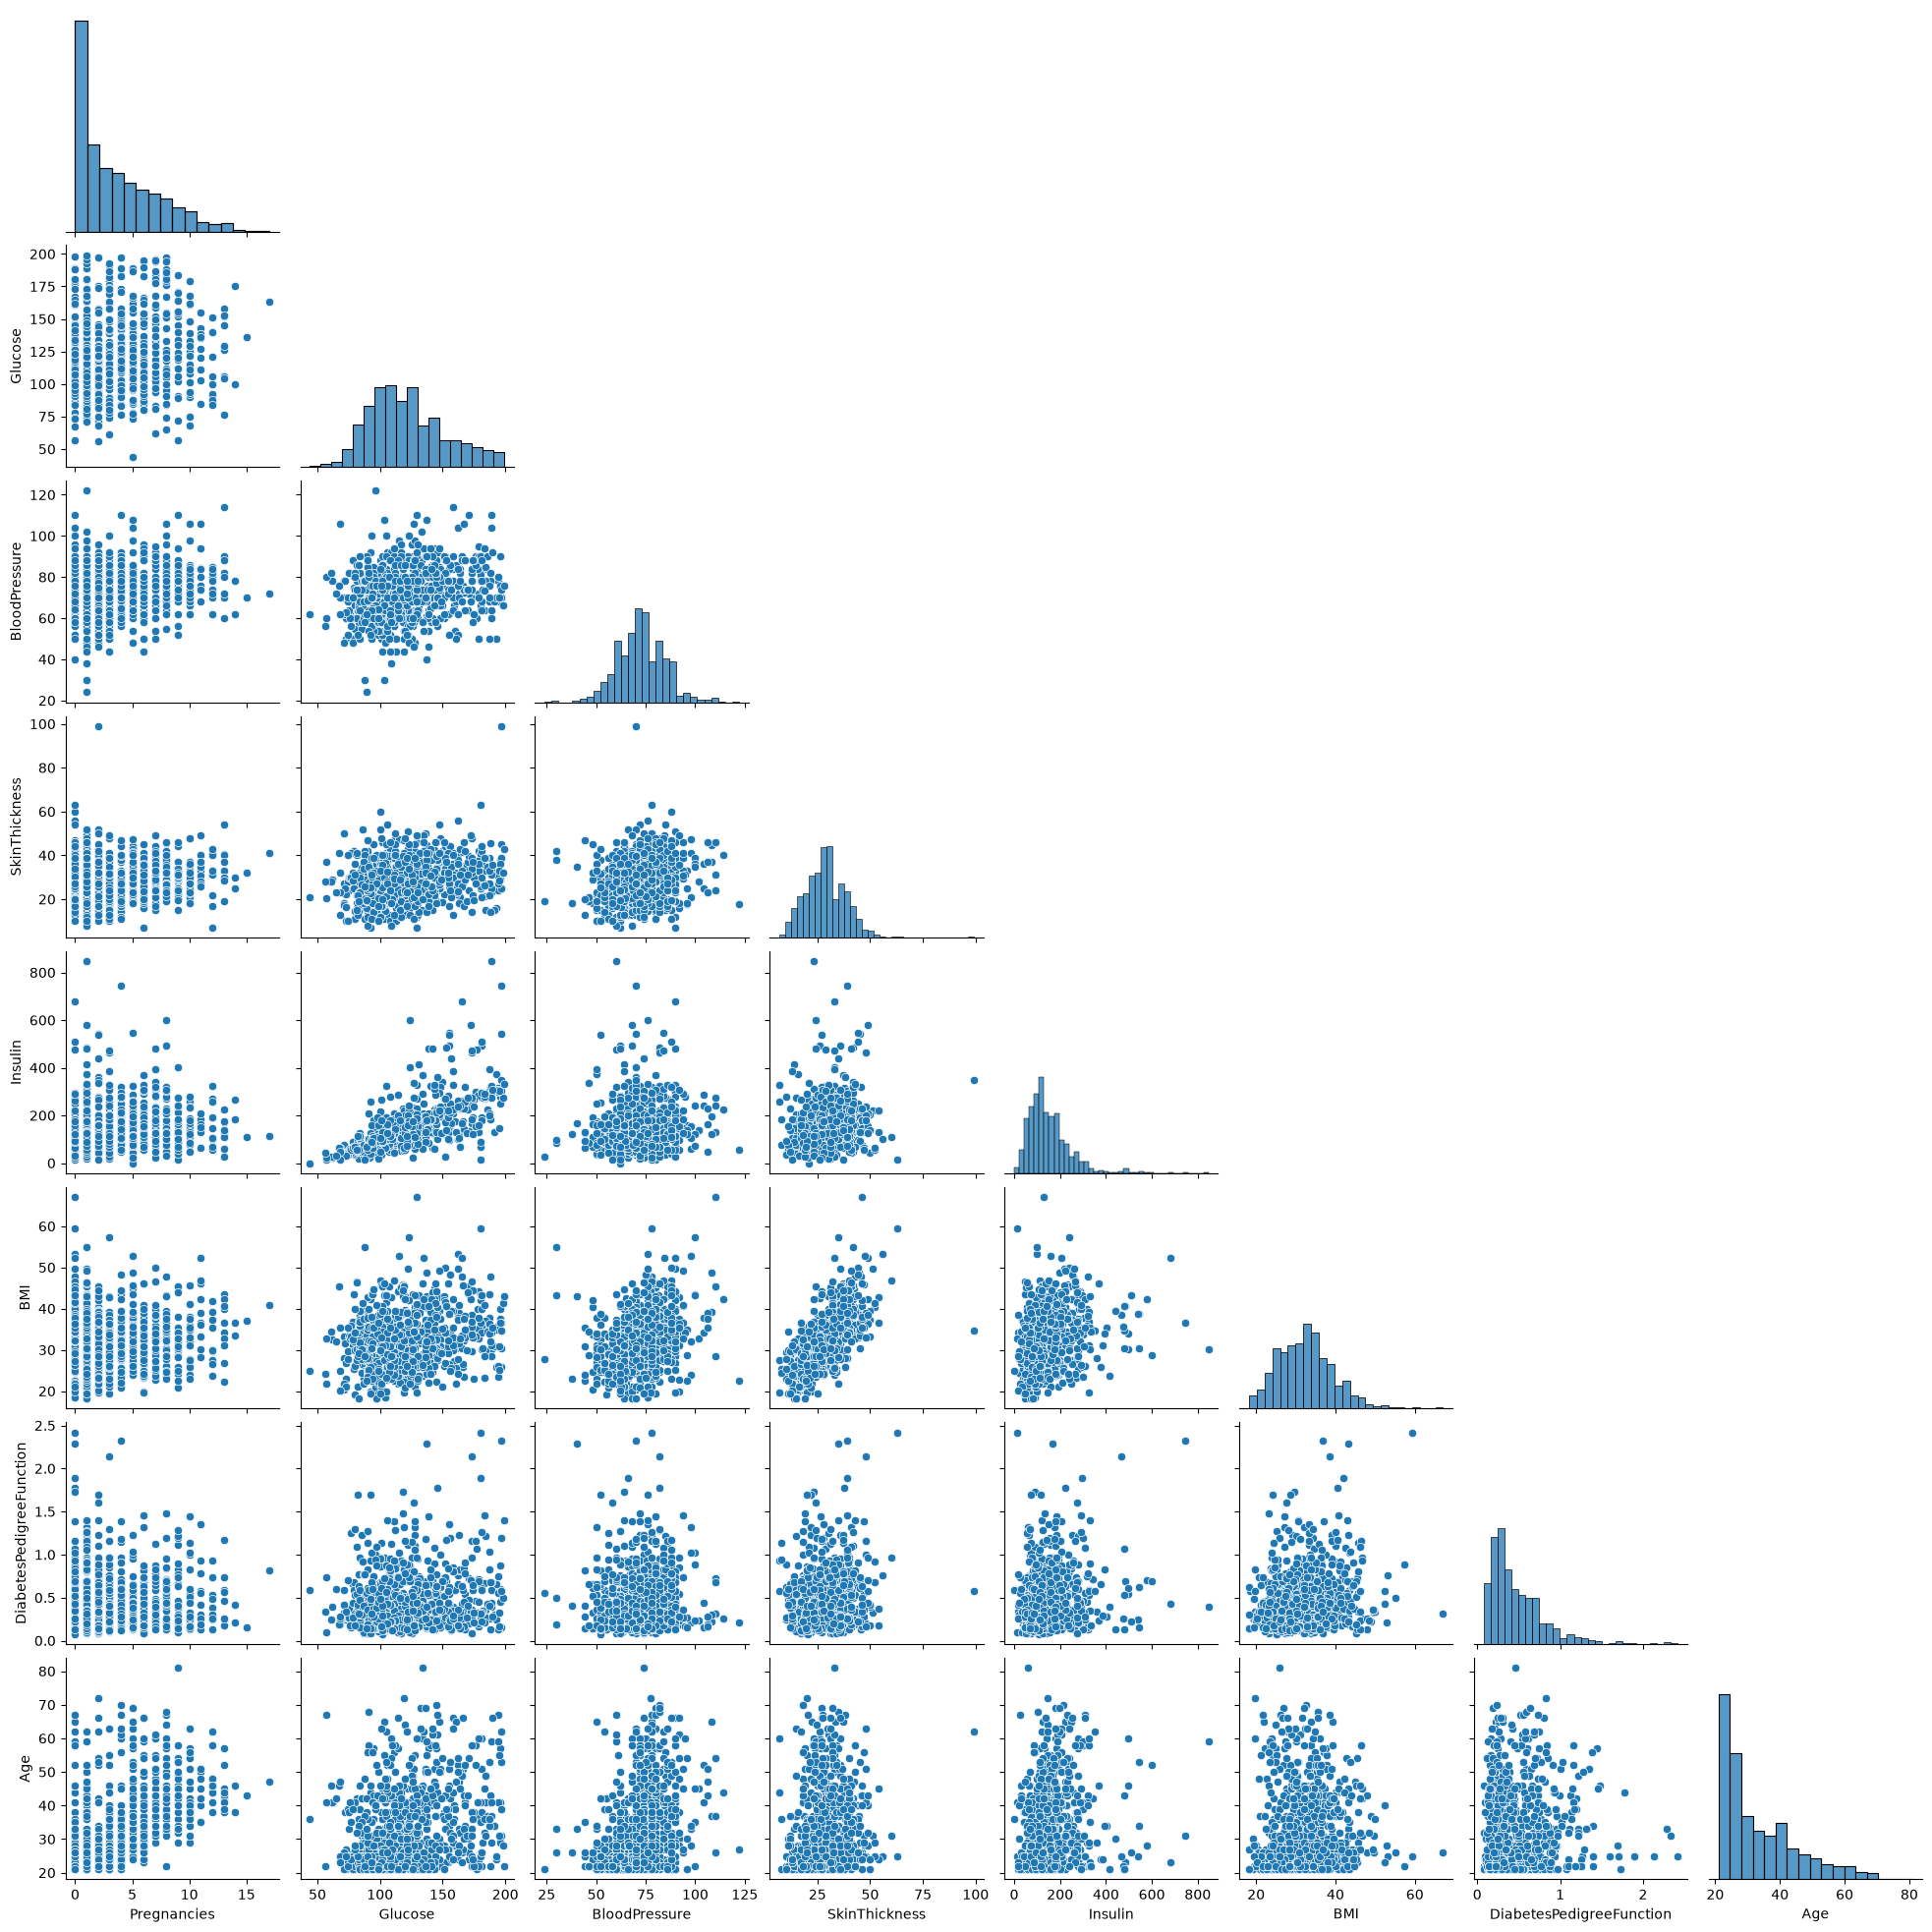

In [8]:
sns.pairplot(df, diag_kind="hist", corner=True)
plt.savefig("../notebooks/pairplot.png")
plt.show()

## 2.5 Scaling (RobustScaler)

RobustScaler used instead of StandardScaler so extreme Insulin values don't distort distance calculations in K-Means.

In [9]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print(df_scaled.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   761.000000  761.000000     761.000000     761.000000  761.000000   
mean      0.168200    0.119200       0.024334       0.022988    0.226211   
std       0.674098    0.743011       0.762209       0.735551    0.975158   
min      -0.600000   -1.780488      -3.000000      -1.663770   -1.306228   
25%      -0.400000   -0.414634      -0.500000      -0.509924   -0.406228   
50%       0.000000    0.000000       0.000000       0.000000    0.000000   
75%       0.600000    0.585366       0.500000       0.490076    0.593772   
max       2.800000    2.000000       3.125000       5.413153    7.153772   

              BMI  DiabetesPedigreeFunction         Age  
count  761.000000                761.000000  761.000000  
mean     0.016927                  0.249678    0.254309  
std      0.759161                  0.862201    0.692910  
min     -1.549451                 -0.779221   -0.470588  
25%     -0.527473        

# Step 3 — K-Means Clustering

## 3.1 Choosing k (elbow + silhouette)

k=2: inertia=2894.96, silhouette=0.2304
k=3: inertia=2563.16, silhouette=0.1807
k=4: inertia=2306.67, silhouette=0.1832
k=5: inertia=2130.12, silhouette=0.1728
k=6: inertia=2003.50, silhouette=0.1767
k=7: inertia=1892.99, silhouette=0.1531


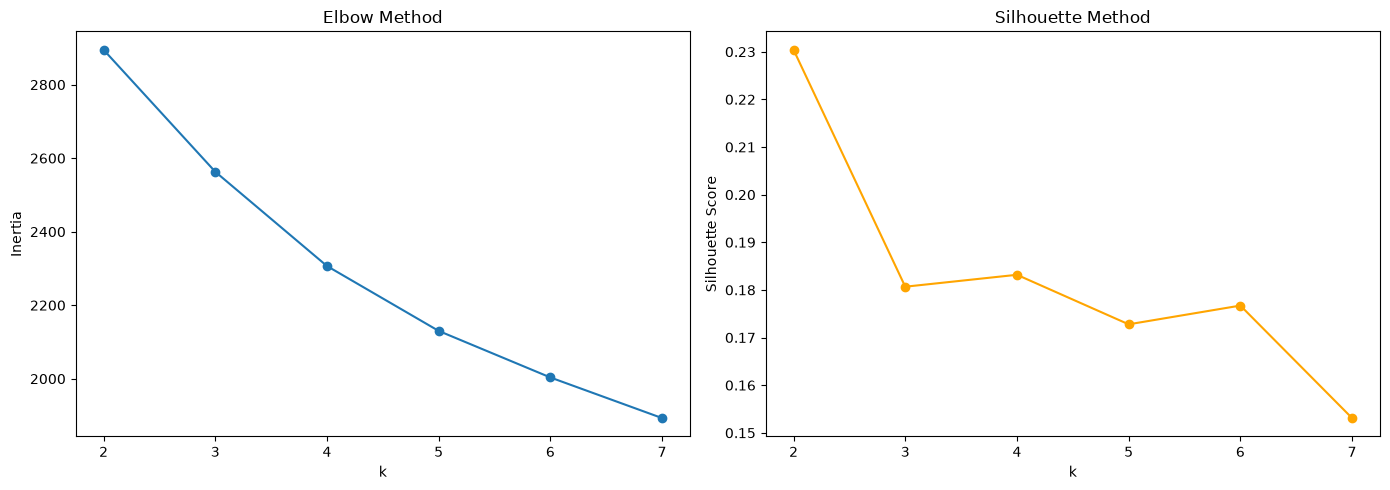

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 8)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(df_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, silhouettes, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Method")

plt.tight_layout()
plt.savefig("../notebooks/elbow_silhouette.png")
plt.show()

k=2 gives the highest silhouette score (0.2304), clearly ahead of k=3+.

## 3.2 Final model

In [11]:
final_km = KMeans(n_clusters=2, random_state=42, n_init=10)
df["Cluster"] = final_km.fit_predict(df_scaled)

print(df["Cluster"].value_counts())
print(df.groupby("Cluster").mean())

Cluster
0    465
1    296
Name: count, dtype: int64
         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
Cluster                                                                      
0           3.015054  105.909375      68.420465      25.490934  106.599763   
1           5.138514  146.987526      78.624227      34.327079  226.519204   

               BMI  DiabetesPedigreeFunction        Age  
Cluster                                                  
0        30.029926                  0.421705  29.068817  
1        36.262181                  0.556476  40.006757  


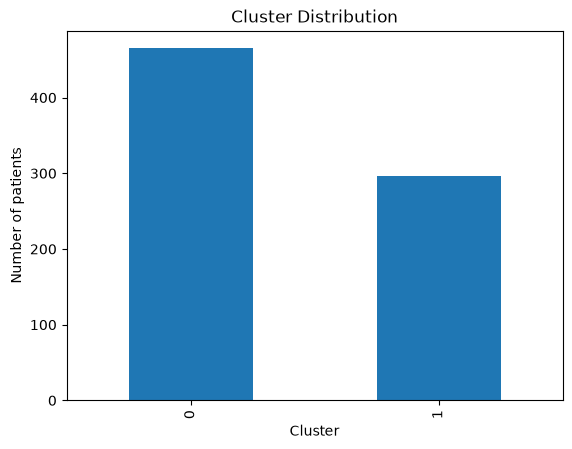

In [12]:
df["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of patients")
plt.title("Cluster Distribution")
plt.savefig("../notebooks/cluster_distribution.png")
plt.show()

# Step 4 — Cluster Interpretation & Risk Labeling

Cluster 1 (296 patients) clears all three thresholds: Glucose 146.99 (>126), BMI 36.26 (>30), DPF 0.556 (>0.5) → high risk.
Cluster 0 (465 patients) does not → low risk.

In [13]:
df["risk_category"] = df["Cluster"].map({0: 0, 1: 1})

print(df["risk_category"].value_counts())

risk_category
0    465
1    296
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["Cluster", "risk_category"])
y = df["risk_category"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
) 


print(x_train.shape, x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())




(608, 8) (153, 8)
risk_category
0    372
1    236
Name: count, dtype: int64
risk_category
0    93
1    60
Name: count, dtype: int64


In [21]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)

print(y_train_resampled.value_counts())


risk_category
0    372
1    372
Name: count, dtype: int64
